# 02 · Analysis — the production story of the Volve field

Three questions a production data analyst answers for the asset team:

1. **Contribution** — which wells sustain the field?
2. **Well health** — when did water arrive in each well, and how fast did it take over?
3. **Losses** — how much oil was lost to downtime, where and when?

KPIs are computed in **SQL (DuckDB)** from [`sql/kpis.sql`](../sql/kpis.sql); Python is used for the time-series logic and the charts.

In [1]:
import re
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

DATA = Path("../data/processed/volve_daily.parquet")
IMAGES = Path("../images")
IMAGES.mkdir(exist_ok=True)

con = duckdb.connect()
con.execute(f"CREATE VIEW daily AS SELECT * FROM '{DATA.as_posix()}'")

# Load every query of sql/kpis.sql by its '-- name:' tag
sql_text = Path("../sql/kpis.sql").read_text(encoding="utf-8")
QUERIES = dict(re.findall(r"-- name: (\w+)\n(.*?)(?=\n-- name:|\Z)", sql_text, re.S))

def run(name: str) -> pd.DataFrame:
    return con.execute(QUERIES[name]).df()

list(QUERIES)

['well_totals', 'monthly_well', 'yearly_field', 'downtime_loss']

In [2]:
# One fixed colour per well, used in every chart (validated for colour-blind separation)
WELL_COLORS = {
    "F-12": "#2a78d6", "F-14": "#eb6834", "F-11": "#1baf7a",
    "F-1C": "#eda100", "F-15D": "#e87ba4", "F-5": "#008300",
}
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "lines.linewidth": 2, "figure.dpi": 110, "axes.axisbelow": True,
})
thousands = mtick.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}k")

## 1 · Contribution — which wells sustain the field?

In [3]:
totals = run("well_totals")
totals

,well,first_oil,last_oil,oil_sm3,water_sm3,oil_share_pct,cumulative_share_pct,lifetime_water_cut,lifetime_gor
0,F-12,2008-02-12,2016-08-12,4579610.0,6833792.0,45.6,45.6,0.599,145.8
1,F-14,2008-07-13,2016-07-13,3942233.0,7121310.0,39.3,84.9,0.644,146.6
2,F-11,2013-07-24,2016-09-17,1147849.0,1090806.0,11.4,96.3,0.487,151.9
3,F-1C,2014-04-22,2016-04-06,177709.0,207302.0,1.8,98.1,0.538,148.8
4,F-15D,2014-01-16,2016-07-06,148519.0,52366.0,1.5,99.6,0.261,151.5
5,F-5,2016-04-20,2016-08-26,41161.0,13533.0,0.4,100.0,0.247,159.4


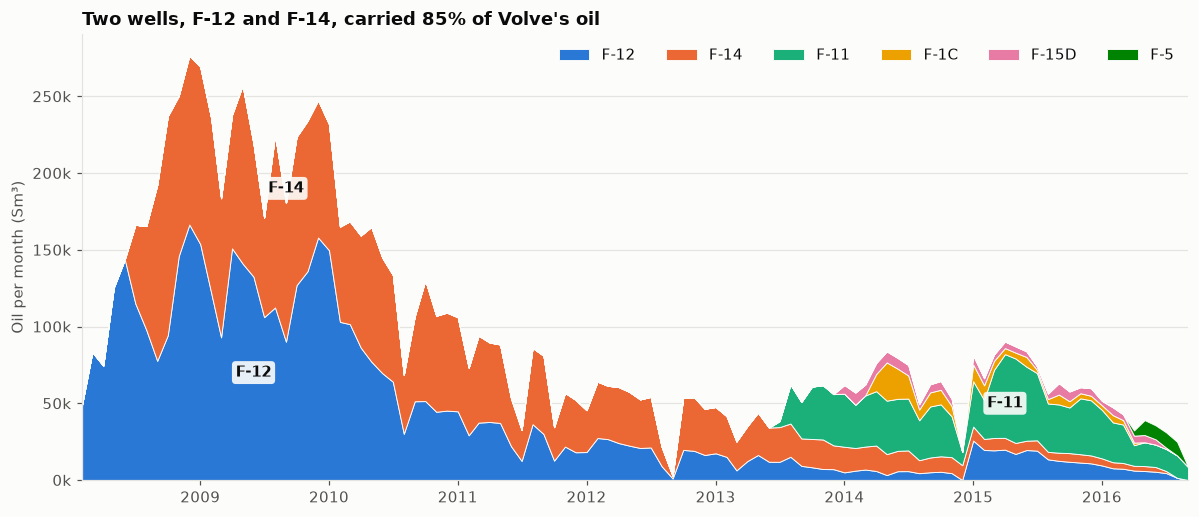

In [4]:
monthly = run("monthly_well")
oil = (monthly.pivot_table(index="month", columns="well", values="oil_sm3", aggfunc="sum")
       .fillna(0)[list(WELL_COLORS)])

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.stackplot(oil.index, oil.T.values, colors=WELL_COLORS.values(), labels=oil.columns,
             edgecolor=SURFACE, linewidth=0.6)
ax.yaxis.set_major_formatter(thousands)
ax.set_ylabel("Oil per month (Sm³)")
ax.set_title("Two wells, F-12 and F-14, carried 85% of Volve's oil")
ax.legend(ncol=6, loc="upper right", frameon=False)

# Direct labels for the bands that are wide enough to read
for well, (x, y) in {"F-12": ("2009-06-01", 70_000), "F-14": ("2009-09-01", 190_000),
                     "F-11": ("2015-04-01", 50_000)}.items():
    ax.annotate(well, (pd.Timestamp(x), y), color=INK, fontweight="bold", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.25", fc=SURFACE, ec="none", alpha=0.9))
ax.set_xlim(oil.index.min(), oil.index.max())
fig.tight_layout()
fig.savefig(IMAGES / "01_field_production.png", dpi=150)
plt.show()

**Reading:** production peaked in 2009 (~2.7 million Sm³ that year) on F-12 and F-14 alone. From 2013 the infill wells (F-11, F-15D, F-1C) slowed the decline but never replaced the two original producers.

## 2 · Well health — when did water arrive?

**Water breakthrough** is defined here as the first month in which the water cut reaches **10%** and stays at or above it for **3 consecutive months**. That ignores one-off spikes (F-12 shows 11% in May 2008, then drops back below 1%).

In [5]:
PRODUCERS = ["F-12", "F-14", "F-11", "F-1C", "F-15D"]
wc = monthly[monthly["oil_sm3"] + monthly["water_sm3"] > 0].pivot(index="month", columns="well", values="water_cut")

def breakthrough(series: pd.Series, threshold: float = 0.10, months: int = 3):
    above = series.dropna() >= threshold
    sustained = above.rolling(months).sum() == months
    if not sustained.any():
        return pd.NaT
    return sustained.idxmax() - pd.DateOffset(months=months - 1)

first_oil = totals.set_index("well")["first_oil"]
bt = pd.DataFrame({
    "first_oil": first_oil[PRODUCERS],
    "breakthrough": [breakthrough(wc[w]) for w in PRODUCERS],
})
bt["months_to_breakthrough"] = ((bt["breakthrough"] - bt["first_oil"]).dt.days / 30.44).round(0)
bt["water_cut_last_12m"] = [wc[w].dropna().iloc[-12:].mean().round(2) for w in PRODUCERS]
bt

,first_oil,breakthrough,months_to_breakthrough,water_cut_last_12m
well,,,,
F-12,2008-02-12,2010-01-01,23.0,0.82
F-14,2008-07-13,2009-08-01,13.0,0.96
F-11,2013-07-24,2014-04-01,8.0,0.75
F-1C,2014-04-22,2014-07-01,2.0,0.74
F-15D,2014-01-16,2015-08-01,18.0,0.50


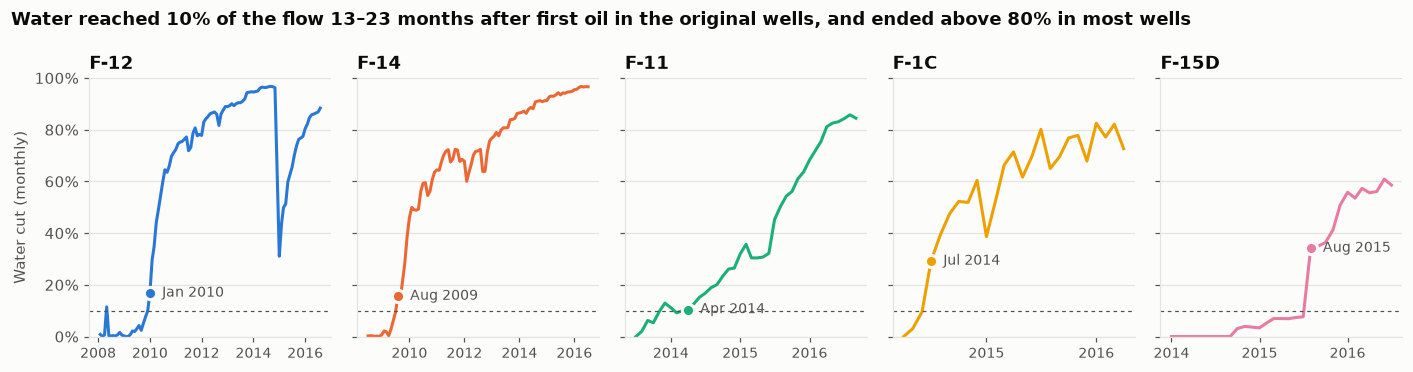

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(13, 3.4), sharey=True)
for ax, well in zip(axes, PRODUCERS):
    s = wc[well].dropna()
    ax.plot(s.index, s.values, color=WELL_COLORS[well])
    ax.axhline(0.10, color=INK_2, linewidth=0.8, linestyle=(0, (3, 3)))
    if pd.notna(bt.loc[well, "breakthrough"]):
        x = bt.loc[well, "breakthrough"]
        ax.plot(x, s.loc[x], "o", color=WELL_COLORS[well], markersize=8, markeredgecolor=SURFACE, markeredgewidth=2)
        ax.annotate(f"{x:%b %Y}", (x, s.loc[x]), xytext=(8, 0), textcoords="offset points",
                    color=INK_2, fontsize=9, va="center")
    ax.set_title(well)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, 1)
    years = s.index.max().year - s.index.min().year
    ax.xaxis.set_major_locator(mdates.YearLocator(base=2 if years > 4 else 1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=9)
axes[0].set_ylabel("Water cut (monthly)")
fig.suptitle("Water reached 10% of the flow 13–23 months after first oil in the original wells, and ended above 80% in most wells",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(IMAGES / "02_water_cut.png", dpi=150)
plt.show()

In [7]:
field = run("yearly_field")
field

,year,oil_sm3,water_sm3,water_injected_sm3,water_cut,producer_efficiency
0,2007,0.0,0.0,0.0,NaN,NaN
1,2008,1764375.0,23523.0,2417770.0,0.013,0.709
2,2009,2684392.0,232105.0,4392198.0,0.080,0.908
3,2010,1689903.0,1887595.0,4569394.0,0.528,0.942
4,2011,847965.0,2190640.0,3442446.0,0.721,0.841
5,2012,574206.0,2110119.0,2975214.0,0.786,0.883
6,2013,558013.0,2576366.0,3453761.0,0.822,0.867
7,2014,743107.0,2716071.0,3825493.0,0.785,0.856
8,2015,861749.0,2009826.0,3201627.0,0.700,0.835
9,2016,313370.0,1572866.0,2052229.0,0.834,0.760


**Reading:** F-14 broke through in Aug 2009 (13 months after first oil) and F-12 in Jan 2010 (23 months); both ended above 80% water cut. The infill wells watered out faster: F-1C within 2 months, F-11 within 8. The sharp dip on F-12 in early 2015 follows months of very low output in late 2014; water cut often drops for a while after a well is rested, then rebuilds. At field level, by 2013 the field handled ~4.6 Sm³ of water for every Sm³ of oil, while ~3.5 million Sm³/year of water was being injected by F-4 and F-5 to support reservoir pressure. Water handling, not oil, became the main constraint on the facility.

## 3 · Losses — how much oil did downtime cost?

**Method** (query `downtime_loss`): for each well and month, a *reference rate* is the median oil rate of the days with ≥ 23 h on stream. Every hour the well was not flowing, inside its producing life, is valued at that rate.

> ⚠️ This is an **upper-bound estimate**. It assumes the well would have kept its recent full-day rate. Long shut-ins of declining wells (e.g., F-1C) are probably over-valued.

In [8]:
loss = run("downtime_loss")
by_well = (loss.groupby("well")[["produced_oil_sm3", "lost_oil_sm3", "lost_full_day_stops_sm3",
                                  "lost_partial_days_sm3", "full_stop_days"]].sum()
           .sort_values("lost_oil_sm3", ascending=False))
by_well["lost_vs_produced_pct"] = (100 * by_well["lost_oil_sm3"] / by_well["produced_oil_sm3"]).round(1)
by_well

,produced_oil_sm3,lost_oil_sm3,lost_full_day_stops_sm3,lost_partial_days_sm3,full_stop_days,lost_vs_produced_pct
well,,,,,,
F-14,3942233.0,447845.0,232187.0,215658.0,115,11.4
F-12,4579609.0,389590.0,191696.0,197896.0,182,8.5
F-1C,177709.0,104114.0,95808.0,8306.0,279,58.6
F-11,1147850.0,71132.0,29391.0,41740.0,27,6.2
F-15D,148518.0,32655.0,26774.0,5882.0,132,22.0
F-5,41161.0,1699.0,0.0,1699.0,0,4.1


Estimated oil lost to downtime: 1,047,035 Sm³ (10.4% of what was produced)


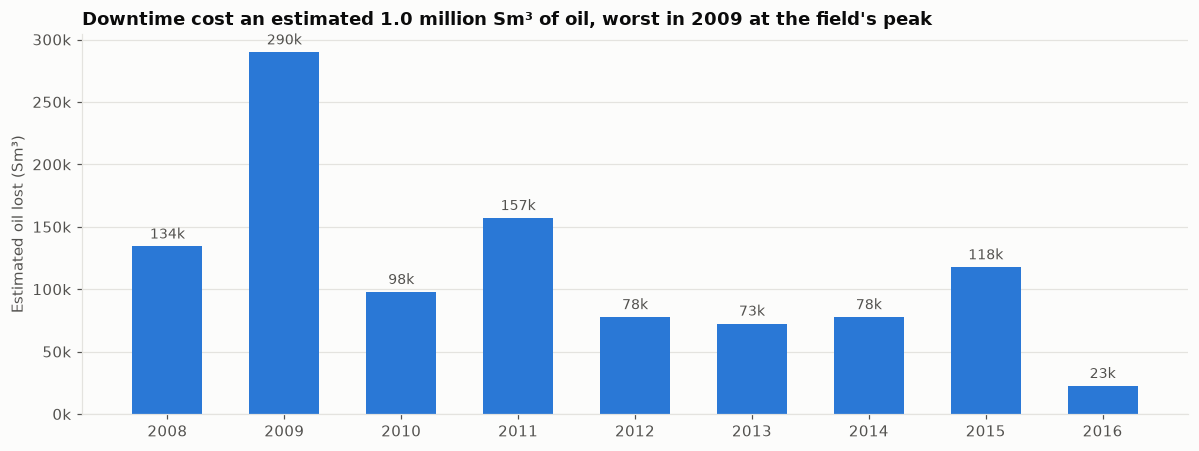

In [9]:
by_year = loss.groupby("year")[["produced_oil_sm3", "lost_oil_sm3"]].sum()
by_year["lost_pct"] = by_year["lost_oil_sm3"] / (by_year["produced_oil_sm3"] + by_year["lost_oil_sm3"])
total_lost = by_year["lost_oil_sm3"].sum()
print(f"Estimated oil lost to downtime: {total_lost:,.0f} Sm³ "
      f"({total_lost / by_year['produced_oil_sm3'].sum():.1%} of what was produced)")

fig, ax = plt.subplots(figsize=(11, 4.2))
bars = ax.bar(by_year.index, by_year["lost_oil_sm3"], color=WELL_COLORS["F-12"], width=0.6)
ax.bar_label(bars, labels=[f"{v / 1e3:,.0f}k" for v in by_year["lost_oil_sm3"]], padding=3, color=INK_2, fontsize=9)
ax.yaxis.set_major_formatter(thousands)
ax.set_ylabel("Estimated oil lost (Sm³)")
ax.set_xticks(by_year.index)
ax.set_title(f"Downtime cost an estimated {total_lost / 1e6:.1f} million Sm³ of oil, worst in 2009 at the field's peak")
fig.tight_layout()
fig.savefig(IMAGES / "03_downtime_loss.png", dpi=150)
plt.show()

**Reading:** the biggest losses happen when the wells are most productive. In 2009 every hour of downtime cost ~190 Sm³ of oil on F-12 and ~150 Sm³ on F-14. F-12 and F-14 together account for ~80% of the estimated loss, roughly half from full-day shut-ins and half from partial days. That split matters operationally: partial days point to trips and restarts, while full days point to planned interventions or well problems.

## Key findings

| # | Finding | Number |
|---|---|---|
| 1 | Two wells carried the field | F-12 + F-14 = **85%** of oil |
| 2 | Water arrived early and took over | Breakthrough **13–23 months** after first oil in the original wells; field water cut **above 70%** from 2011 |
| 3 | Downtime was the largest controllable loss | ~**1.0 million Sm³** estimated (~**10%** of production), peaking in 2009 |

**Next:** `03_decline.ipynb` — decline-curve analysis (Arps) and a 12-month forecast for F-12/F-14; and the Power BI *Daily Production Report*.